In [7]:
import os
import pandas as pd
import geopandas as gpd
from pygris import block_groups
import matplotlib.pyplot as plt

# -----------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------
script_dir = os.getcwd()
out_dir = script_dir
target_crs = "EPSG:26919"
bg_id_col = "GEOID"

lehd_file= "/Users/cpoliziani/Documents/repo/SynthFirm_input_parameter_111125/inputs_Boston/data_mesozone_emprankings_lehd.csv"
ma_file  = "/Users/cpoliziani/Documents/repo/SynthFirm_input_parameter_111125/inputs_Boston/employment/ma_employment_run_113-209_2019_v20250829.csv"
rinh_file= "/Users/cpoliziani/Documents/repo/SynthFirm_input_parameter_111125/inputs_Boston/employment/nhri_employment_2020_v20230518.csv"
ma_file  = "/Users/cpoliziani/Documents/repo/SynthFirm_input_parameter_111125/inputs_Boston/employment/ma_employment_run_113-210_2050_v20250829.csv"
rinh_file= "/Users/cpoliziani/Documents/repo/SynthFirm_input_parameter_111125/inputs_Boston/employment/nhri_employment_2050_v20230518.csv"

taz_shp = "/Users/cpoliziani/Documents/repo/SynthFirm_input_parameter_111125/inputs_Boston/zoning/CTPS_TDM23_TAZ_2017g_v202303.shp"

print("\n[STEP 0] Loading data...")
lehd = pd.read_csv(lehd_file)
ma   = pd.read_csv(ma_file)
rinh = pd.read_csv(rinh_file)
rinh = rinh[rinh["block_id"]<1000000]
# -----------------------------------------------------------------
# 1. Stack + split 15-digit vs 6-digit
# -----------------------------------------------------------------
print("\n[STEP 1] Preparing employment data...")
b = pd.concat([ma, rinh], ignore_index=True)

b["id"] = b["block_id"].astype(str)
b["len"] = b["id"].str.len()

# Employment columns (drop total jobs/households)
emp_cols = [c for c in b.columns if c not in ["block_id","id","len"]]

b15  = b[b["len"]==15].copy()
b6   = b[b["len"]==6].copy()
print("  15-digit rows:", len(b15))
print("  6-digit (TAZ) rows:", len(b6))

# -----------------------------------------------------------------
# 2. 15-digit → block group
# -----------------------------------------------------------------
print("\n[STEP 2] Aggregating 15-digit blocks → block groups...")
b15["id"] = b15["id"].str.zfill(15)
b15["MESOZONE"] = b15["id"].str[:12]

bg_from_blocks = b15.groupby("MESOZONE", as_index=False)[emp_cols].sum()
print("  Block groups from blocks:", len(bg_from_blocks))

# -----------------------------------------------------------------
# 3. 6-digit TAZ → overlay → BG allocation
# -----------------------------------------------------------------
print("\n[STEP 3] Allocating 6-digit TAZ → block groups (area-weighted)...")

if b6.empty:
    print("  No 6-digit rows.")
    bg_from_taz = pd.DataFrame(columns=["MESOZONE"] + emp_cols)
else:
    b6["taz_id"] = b6["id"].astype(int)
    taz_emp = b6.groupby("taz_id", as_index=False)[emp_cols].sum()

    taz = gpd.read_file(taz_shp)
    taz["taz_id"] = taz["taz_id"].astype(int)
    taz = taz.merge(taz_emp, on="taz_id", how="inner")
    
    print('taz associated to unique taz_id form 6-digit Boston codes', len(taz))

    # Load block groups from pygris
    print("  Loading block groups via pygris...")
    ma_bg = block_groups("MA", year=2018)
    nh_bg = block_groups("NH", year=2018)
    ri_bg = block_groups("RI", year=2018)
    bg = pd.concat([ma_bg,nh_bg,ri_bg])[["GEOID","geometry"]]

    # Reproject
    taz = taz.to_crs(target_crs)
    bg  = bg.to_crs(target_crs)

    # Overlay
    print("  Computing BG–TAZ intersections...")
    inter = gpd.overlay(bg, taz[["taz_id","geometry"]+emp_cols], how="intersection")
    inter["overlap"] = inter.area

    a = taz[["taz_id","geometry"]].copy()
    a["taz_area"] = a.area
    inter = inter.merge(a[["taz_id","taz_area"]], on="taz_id")
    inter["w"] = inter["overlap"] / inter["taz_area"]

    # Weighted employment
    for c in emp_cols:
        inter[c] = inter[c] * inter["w"]

    bg_from_taz = inter.groupby("GEOID", as_index=False)[emp_cols].sum()
    bg_from_taz = bg_from_taz.rename(columns={"GEOID":"MESOZONE"})
    print("  Block groups from TAZ:", len(bg_from_taz))

# -----------------------------------------------------------------
# 4. Combine BG from blocks + BG from TAZ
# -----------------------------------------------------------------
print("\n[STEP 4] Combining block groups from MA + NH/RI...")
bg_all = pd.concat([bg_from_blocks, bg_from_taz], ignore_index=True)
bg_all = bg_all.groupby("MESOZONE", as_index=False)[emp_cols].sum()
print("  Total BG:", len(bg_all))

# Convert to integer
bg_all[emp_cols] = bg_all[emp_cols].round(0).astype(int)

# -----------------------------------------------------------------
# 5. Merge with LEHD MESOZONE
# -----------------------------------------------------------------
print("\n[STEP 5] Merging with LEHD MESOZONE...")
lehd["MESOZONE"] = lehd["MESOZONE"].astype(str).str.zfill(12)

final = bg_all.merge(lehd, on="MESOZONE", how="left", indicator=True)
rank_cols = [c for c in final.columns if c.startswith("rank")]
final["lehd_total"] = final[rank_cols].sum(axis=1)

final["diff"] = final["total_jobs"]-final["lehd_total"]


print(final["_merge"].value_counts())
final = final.drop(columns=["_merge"])

# Save
out_csv = os.path.join(out_dir, "boston_employment_lehd_blockgroups.csv")
final.to_csv(out_csv, index=False)
print("\n[SAVED] →", out_csv)

# -----------------------------------------------------------------
# 6. PLOT FINALE
# -----------------------------------------------------------------
print("\n[STEP 6] Plotting block group employment...")

# Load BG polygons again for map plotting
ma_bg = block_groups("MA", year=2018)[["GEOID","geometry"]]
nh_bg = block_groups("NH", year=2018)[["GEOID","geometry"]]
ri_bg = block_groups("RI", year=2018)[["GEOID","geometry"]]
bg_poly = pd.concat([ma_bg,nh_bg,ri_bg])

bg_poly["MESOZONE"] = bg_poly["GEOID"]
gdf_final = bg_poly.merge(final, on="MESOZONE", how="left")





[STEP 0] Loading data...

[STEP 1] Preparing employment data...
  15-digit rows: 131262
  6-digit (TAZ) rows: 1242

[STEP 2] Aggregating 15-digit blocks → block groups...
  Block groups from blocks: 4977

[STEP 3] Allocating 6-digit TAZ → block groups (area-weighted)...
taz associated to unique taz_id form 6-digit Boston codes 1242
  Loading block groups via pygris...
Using FIPS code '25' for input 'MA'
Using FIPS code '33' for input 'NH'
Using FIPS code '44' for input 'RI'
  Computing BG–TAZ intersections...
  Block groups from TAZ: 1320

[STEP 4] Combining block groups from MA + NH/RI...
  Total BG: 6240

[STEP 5] Merging with LEHD MESOZONE...
both          6224
left_only       16
right_only       0
Name: _merge, dtype: int64

[SAVED] → /Users/cpoliziani/Documents/repo/SynthFirm/scenario_analysis/emp_rankings/boston_employment_lehd_blockgroups.csv

[STEP 6] Plotting block group employment...
Using FIPS code '25' for input 'MA'
Using FIPS code '33' for input 'NH'
Using FIPS code '44'

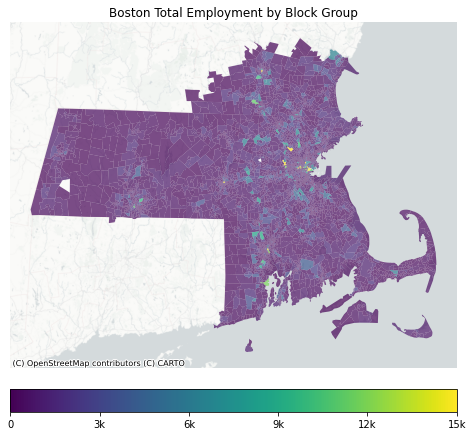

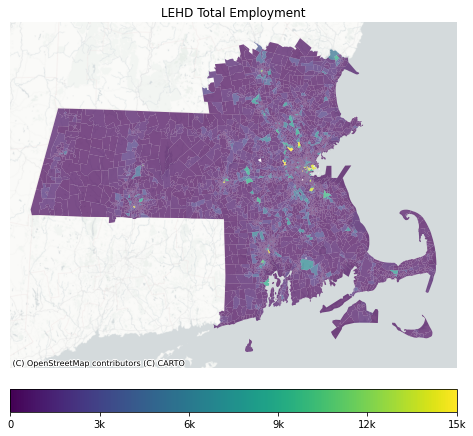

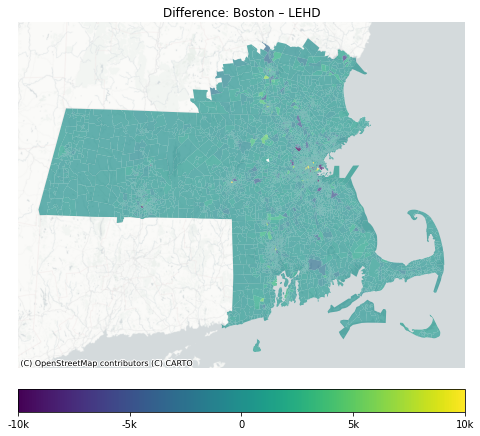

In [8]:
import matplotlib.colors as colors
import matplotlib.cm as cm
import contextily as ctx

cmap = "viridis"

def plot_horiz(gdf, col, title, vmin, vmax, ticks, labels, save_file):
    g = gdf[gdf[col].notnull()].copy()
    g = g.to_crs("EPSG:3857")
    fig, ax = plt.subplots(1, 1, figsize=(8, 10))
    g.plot(column=col, cmap=cmap, ax=ax, vmin=vmin, vmax=vmax, alpha = 0.7)
    ctx.add_basemap(
        ax,
        crs=g.crs.to_string(),
        source=ctx.providers.CartoDB.PositronNoLabels,   # black/white clean
        zoom=9
    )
    sm = cm.ScalarMappable(norm=colors.Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.046, pad=0.04)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(labels)
    ax.set_title(title)
    ax.axis("off")
    plt.savefig(save_file, dpi = 600)

# Boston (0–50k)
plot_horiz(
    gdf_final[gdf_final["total_jobs"] > 0],
    "total_jobs",
    "Boston Total Employment by Block Group",
    0, 15000,
    [0, 3000, 6000, 9000, 12000, 15000],
    ["0", "3k", "6k", "9k", "12k", "15k"],
    'boston_jobs_blkgrp.png'
)

# LEHD (0–50k)
plot_horiz(
    gdf_final[gdf_final["lehd_total"] > 0],
    "lehd_total",
    "LEHD Total Employment",
    0, 15000,
    [0, 3000, 6000, 9000, 12000, 15000],
    ["0", "3k", "6k", "9k", "12k", "15k"],
    'lehd_jobs_blkgrp.png'

)

# Diff (-1k → 10k, clamped)
plot_horiz(
    gdf_final,
    "diff",
    "Difference: Boston – LEHD",
    -10000, 10000,
    [-10000, -5000, 0, 5000, 10000],
    ["-10k", "-5k", "0", "5k", "10k"],    
    'diff_jobs_blkgrp.png'
)


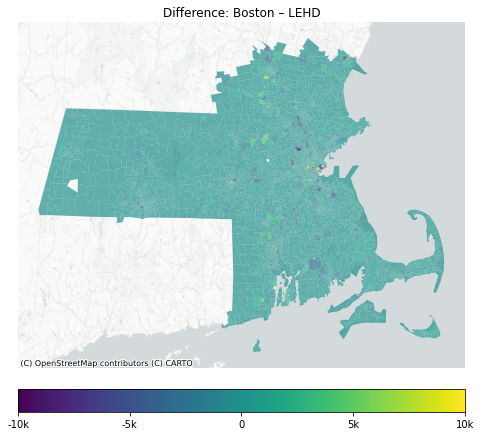

In [9]:
gdf_filter = gdf_final[
    (gdf_final["total_jobs"].notnull()) &
    (gdf_final["total_jobs"] > 0) &
    (gdf_final["lehd_total"].notnull()) &
    (gdf_final["lehd_total"] > 0)
].copy()

plot_horiz(
    gdf_filter,
    "diff",
    "Difference: Boston – LEHD",
    -10000, 10000,
    [-10000, -5000, 0, 5000, 10000],
    ["-10k", "-5k", "0", "5k", "10k"],    
    'diff_jobs_blkgrp.png'
)

In [10]:
gdf_filter['diff'].sum()

399160.0

In [11]:
gdf_filter.lehd_total.sum()

4365112.0

In [12]:
gdf_filter.total_jobs.sum()

4764272.0